# Atividade Aula 2.7 - Regressão Linear com PyTorch


Dataset: `harlfoxem/housesalesprediction`


## Importação dos pacotes

In [ ]:
%matplotlib inline

import os
import glob
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(1234)
np.random.seed(1234)


## Leitura dos dados

O código abaixo baixa o dataset pelo `kagglehub`, conforme indicado na página do Kaggle.


In [ ]:
!pip install kagglehub -q



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import kagglehub

path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

print("Path to dataset files:", path)
print("Arquivos encontrados:")
print(os.listdir(path))


Using Colab cache for faster access to the 'housesalesprediction' dataset.
Path to dataset files: /kaggle/input/housesalesprediction
Arquivos encontrados:
['kc_house_data.csv']


In [ ]:

csv_files = glob.glob(os.path.join(path, "*.csv"))

print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()


['/kaggle/input/housesalesprediction/kc_house_data.csv']


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Seleção das variáveis

Para fazer a regressão linear, vamos usar algumas características numéricas da casa para prever o preço (`price`).


In [ ]:

df.columns


Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [ ]:
# Seleção de atributos de entrada
features = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated',
    'lat',
    'long',
    'sqft_living15',
    'sqft_lot15'
]

target = 'price'

# Removendo valores nulos, se existirem
df_model = df[features + [target]].dropna()

X = df_model[features].values.astype(np.float32)
y = df_model[[target]].values.astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (21613, 17)
y shape: (21613, 1)


## Normalização dos dados

Assim como no notebook base, os dados são normalizados antes do treinamento.


In [ ]:
# Normalizando X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalizando y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)


In [ ]:
# Divisão entre treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.3,
    random_state=42
)

# Convertendo para tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)


X_train_tensor shape: torch.Size([15129, 17])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 17])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

Como agora usamos várias variáveis de entrada, o número de entradas do modelo será igual ao número de atributos selecionados.


In [ ]:
n_features = X_train_tensor.shape[1]

model = torch.nn.Linear(n_features, 1)

print(model)


Linear(in_features=17, out_features=1, bias=True)


### Testando o predict da rede

In [ ]:
model(X_train_tensor[:5])


tensor([[-0.2862],
        [ 0.5068],
        [-0.4658],
        [-1.3904],
        [-0.7227]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


### Funções de treinamento e validação

In [ ]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train()
    optimizer.zero_grad()

    # Forward
    outputs = model(X_train)

    # Loss
    loss = criterion(outputs, y_train)

    # Backward
    loss.backward()

    # Atualização dos pesos
    optimizer.step()

    return loss.item()


In [ ]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval()

    with torch.no_grad():
        outputs = model(X_val)
        loss = criterion(outputs, y_val)

    return loss.item()


### Laço de treinamento

In [ ]:
num_epochs = 300

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_epoch(
        model,
        optimizer,
        criterion,
        X_train_tensor,
        y_train_tensor
    )

    val_loss = validate_epoch(
        model,
        criterion,
        X_val_tensor,
        y_val_tensor
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')


Epoch [50/300], Train Loss: 0.343481, Val Loss: 0.373758
Epoch [100/300], Train Loss: 0.313599, Val Loss: 0.342015
Epoch [150/300], Train Loss: 0.303929, Val Loss: 0.332556
Epoch [200/300], Train Loss: 0.299828, Val Loss: 0.329059
Epoch [250/300], Train Loss: 0.297806, Val Loss: 0.327633
Epoch [300/300], Train Loss: 0.296721, Val Loss: 0.327039


## Avaliação do modelo

In [ ]:
# Predict com os dados de treino e validação
model.eval()

with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)

# MSE normalizado
train_mse = criterion(y_pred_train, y_train_tensor)
val_mse = criterion(y_pred_val, y_val_tensor)

print("MSE treino normalizado:", train_mse.item())
print("MSE validação normalizado:", val_mse.item())


MSE treino normalizado: 0.29670482873916626
MSE validação normalizado: 0.32703933119773865


In [ ]:
# Convertendo os valores para a escala original de preço
y_train_original = y_scaler.inverse_transform(y_train_tensor.numpy())
y_val_original = y_scaler.inverse_transform(y_val_tensor.numpy())

y_pred_train_original = y_scaler.inverse_transform(y_pred_train.numpy())
y_pred_val_original = y_scaler.inverse_transform(y_pred_val.numpy())

train_mse_original = mean_squared_error(y_train_original, y_pred_train_original)
val_mse_original = mean_squared_error(y_val_original, y_pred_val_original)

train_r2 = r2_score(y_train_original, y_pred_train_original)
val_r2 = r2_score(y_val_original, y_pred_val_original)

print("MSE treino na escala original:", train_mse_original)
print("MSE validação na escala original:", val_mse_original)
print("R² treino:", train_r2)
print("R² validação:", val_r2)


MSE treino na escala original: 39988731904.0
MSE validação na escala original: 44077101056.0
R² treino: 0.6939151287078857
R² validação: 0.6946861743927002


## Gráfico da perda

O gráfico abaixo mostra a evolução da perda durante o treinamento.


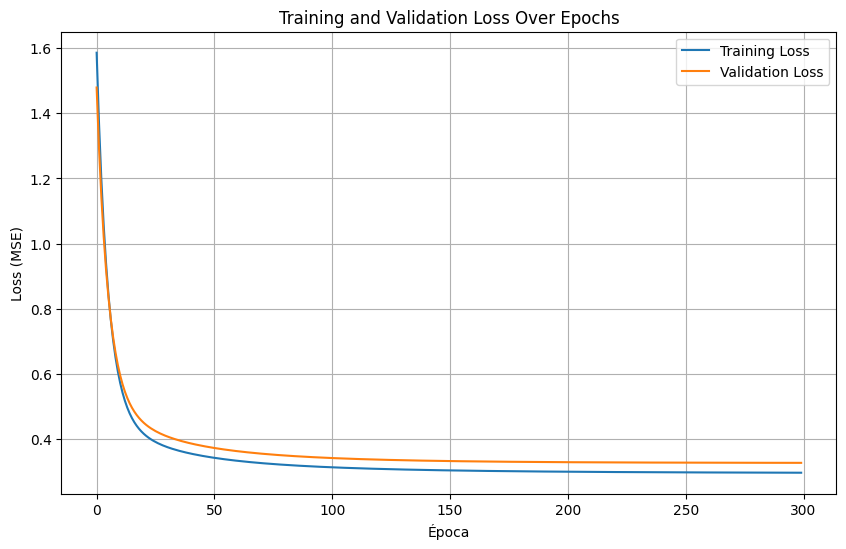

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


## Comparação entre valores reais e previstos

O gráfico abaixo compara os preços reais com os preços previstos pelo modelo.


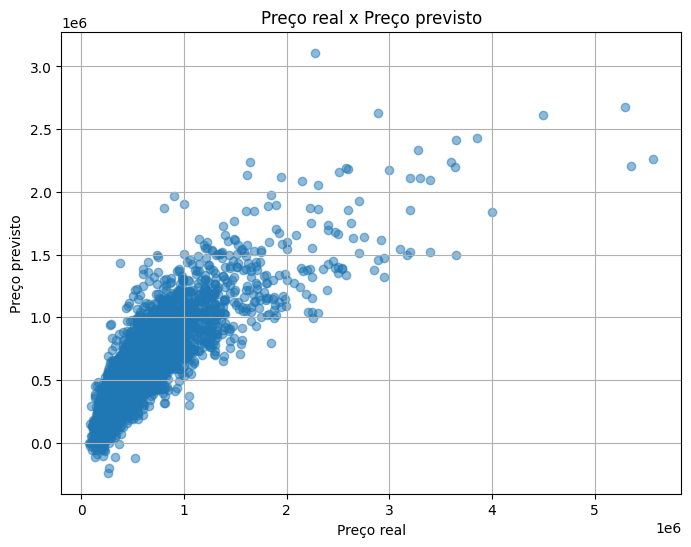

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val_original, y_pred_val_original, alpha=0.5)
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.title('Preço real x Preço previsto')
plt.grid(True)
plt.show()


## Aprendizados

Durante essa atividade eu consegui entender melhor como adaptar um modelo de regressão linear para um dataset diferente. Foi interessante perceber que, ao mudar do dataset de salário para o dataset de casas, também foi necessário alterar as variáveis de entrada e ajustar o tamanho da camada linear. Além disso, a normalização ajudou no treinamento e os gráficos facilitaram a visualização da evolução da perda e da comparação entre os valores reais e previstos.
